## Train/Test
Evaluate Your Model
In Machine Learning we create models to predict the outcome of certain events, like in the previous chapter where we predicted the CO2 emission of a car when we knew the weight and engine size.

To measure if the model is good enough, we can use a method called Train/Test.

##  What is Train/Test
Train/Test is a method to measure the accuracy of your model.

It is called Train/Test because you split the data set into two sets: a training set and a testing set.

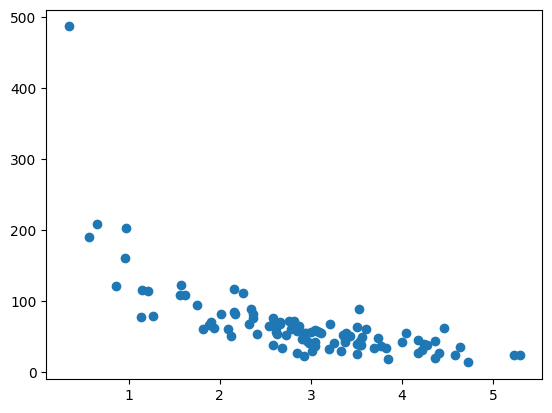

In [1]:
# Start with a data set you want to test.

# Our data set illustrates 100 customers in a shop, and their shopping habits.

import numpy
import matplotlib.pyplot as plt
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

plt.scatter(x, y)
plt.show()

##  Result:
The x axis represents the number of minutes before making a purchase.

The y axis represents the amount of money spent on the purchase.

#   Split Into Train/Test
The training set should be a random selection of 80% of the original data.

The testing set should be the remaining 20%.

In [2]:
train_x = x[:80]
train_y = y[:80]

test_x = x[80:]
test_y = y[80:]

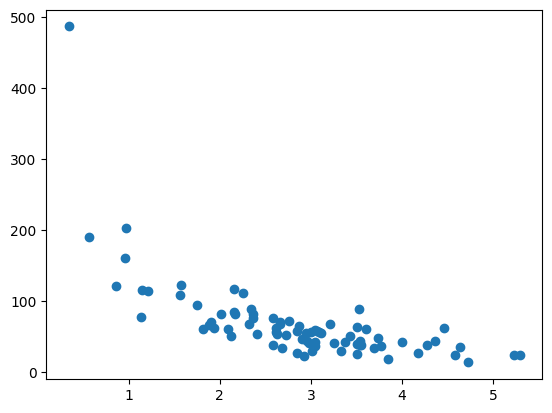

In [3]:
# Display the same scatter plot with the training set:
plt.scatter(train_x, train_y)
plt.show()

#   Display the Testing Set
To make sure the testing set is not completely different, we will take a look at the testing set as well.


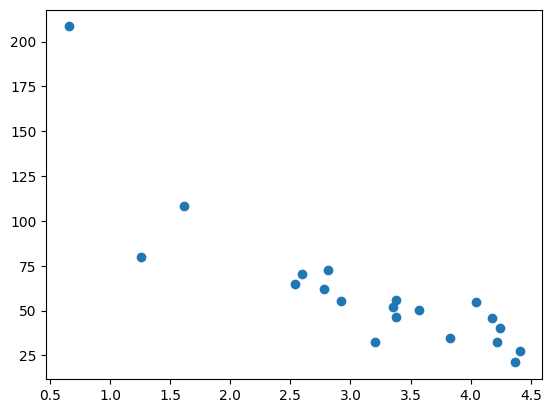

In [4]:
plt.scatter(test_x, test_y)
plt.show()

##  Fit the Data Set
What does the data set look like? In my opinion I think the best fit would be a polynomial regression, so let us draw a line of polynomial regression.

To draw a line through the data points, we use the plot() method of the matplotlib module:

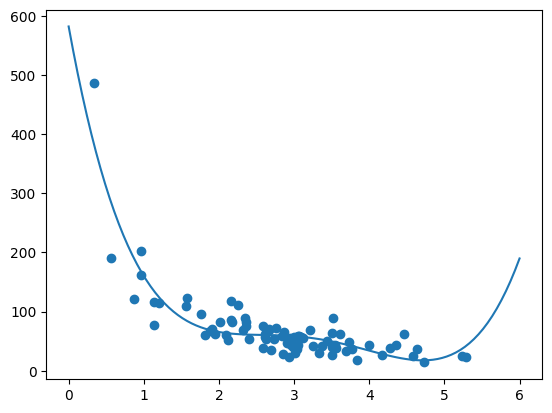

In [5]:
# Draw a polynomial regression line through the data points:

import numpy
import matplotlib.pyplot as plt
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

train_x = x[:80]
train_y = y[:80]

test_x = x[80:]
test_y = y[80:]

mymodel = numpy.poly1d(numpy.polyfit(train_x, train_y, 4))

myline = numpy.linspace(0, 6, 100)

plt.scatter(train_x, train_y)
plt.plot(myline, mymodel(myline))
plt.show()

The result can back my suggestion of the data set fitting a polynomial regression, even though it would give us some weird results if we try to predict values outside of the data set. Example: the line indicates that a customer spending 6 minutes in the shop would make a purchase worth 200. That is probably a sign of overfitting.

But what about the R-squared score? The R-squared score is a good indicator of how well my data set is fitting the model.

##  R2
Remember R2, also known as R-squared?

It measures the relationship between the x axis and the y axis, and the value ranges from 0 to 1, where 0 means no relationship, and 1 means totally related.

The sklearn module has a method called r2_score() that will help us find this relationship.

In this case we would like to measure the relationship between the minutes a customer stays in the shop and how much money they spend.

In [6]:
# How well does my training data fit in a polynomial regression?

import numpy
from sklearn.metrics import r2_score
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

train_x = x[:80]
train_y = y[:80]

test_x = x[80:]
test_y = y[80:]

mymodel = numpy.poly1d(numpy.polyfit(train_x, train_y, 4))

r2 = r2_score(train_y, mymodel(train_x))

print(r2)

0.7988645544629797


Note: The result 0.799 shows that there is a OK relationship.

##  Bring in the Testing Set
Now we have made a model that is OK, at least when it comes to training data.

Now we want to test the model with the testing data as well, to see if gives us the same result.

In [7]:
# Find the R2 score when using testing data:

import numpy
from sklearn.metrics import r2_score
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

train_x = x[:80]
train_y = y[:80]

test_x = x[80:]
test_y = y[80:]

mymodel = numpy.poly1d(numpy.polyfit(train_x, train_y, 4))

r2 = r2_score(test_y, mymodel(test_x))

print(r2)

0.8086921460343581


Note: The result 0.809 shows that the model fits the testing set as well, and we are confident that we can use the model to predict future values.

##  Predict Values
Now that we have established that our model is OK, we can start predicting new values.

How much money will a buying customer spend, if she or he stays in the shop for 5 minutes?

In [8]:
print(mymodel(5))

22.87962591811811


The example predicted the customer to spend 22.88 dollars, as seems to correspond to the diagram: